# Tarea 1 - Semana 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, zscore

In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

In [3]:
df = pd.read_csv(
    '../data/raw/adult.data',
    header=None,
    names=columns
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
##Hacemos una copia

df_reto = df.copy()

In [5]:
##Convertir " ?" en NaN

df_reto = df_reto.replace(' ?', np.nan)

In [6]:
numeric_cols = df_reto.select_dtypes(include='number').columns

numeric_cols

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

# Medimos el skewness

In [7]:
#No debemos ignorar variables muy sesgadas negativamente 
##Por ello usaremos valor absoluto

skewness = df_reto[numeric_cols].skew().abs().sort_values(ascending=False)

skewness

capital-gain      11.953848
capital-loss       4.594629
fnlwgt             1.446980
age                0.558743
education-num      0.311676
hours-per-week     0.227643
dtype: float64

In [8]:
# Nos quedamos con las 3 más sesgadas

top_3_skewed = skewness.head(3)

top_3_skewed

capital-gain    11.953848
capital-loss     4.594629
fnlwgt           1.446980
dtype: float64

# IQR 

In [9]:
iqr_results = []

for col in top_3_skewed.index:
    Q1 = df_reto[col].quantile(0.25)
    Q3 = df_reto[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    mask = (df_reto[col]<lower) | (df_reto[col]>upper)

    iqr_results.append({
        'column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound':lower,
        'upper_bound':upper,
        'outlier_count': mask.sum()
    })

iqr_results = pd.DataFrame(iqr_results)

iqr_results
    

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,capital-gain,0.0,0.0,0.0,0.0,0.0,2712
1,capital-loss,0.0,0.0,0.0,0.0,0.0,1519
2,fnlwgt,117827.0,237051.0,119224.0,-61009.0,415887.0,992


# Z-score: crudo vs log1p

In [10]:
#Analizamos la variable capital-gain

df_reto['capital-gain'].describe()

count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

In [11]:
z_raw = zscore(df_reto['capital-gain'])

raw_outliers = np.abs(z_raw) > 3

raw_outliers.sum()

np.int64(215)

In [12]:
df_reto.loc[raw_outliers, 'capital-gain'].describe()

count      215.000000
mean     81289.209302
std      31648.421028
min      25124.000000
25%      37702.500000
50%      99999.000000
75%      99999.000000
max      99999.000000
Name: capital-gain, dtype: float64

In [13]:
df_reto.loc[raw_outliers, 'capital-gain'].head(10)

106     34095
704     25236
1246    99999
1368    99999
1482    99999
1528    99999
1562    25124
1616    99999
1682    99999
1764    27828
Name: capital-gain, dtype: int64

In [14]:
capital_gain_log = np.log1p(df_reto['capital-gain'])

In [15]:
capital_gain_log.skew()

np.float64(3.096143524467517)

In [16]:
df_reto['capital-gain'].skew()

np.float64(11.953847687699799)

In [17]:
print("Skewness original:", df_reto['capital-gain'].skew())
print("Skewness después de log1p:", capital_gain_log.skew())

Skewness original: 11.953847687699799
Skewness después de log1p: 3.096143524467517


In [18]:
z_log = zscore(capital_gain_log)

In [19]:
log_outliers = np.abs(z_log) > 3

log_outliers.sum()

np.int64(2100)

In [20]:
zscore_comparison = pd.DataFrame({
    'transformacion': ['raw', 'log1p'],
    'skewness': [
        df_reto['capital-gain'].skew(),
        capital_gain_log.skew()
    ],
    'outliers_z_gt_3': [
        raw_outliers.sum(),
        log_outliers.sum()
    ]
})

zscore_comparison

,transformacion,skewness,outliers_z_gt_3
0,raw,11.953848,215
1,log1p,3.096144,2100


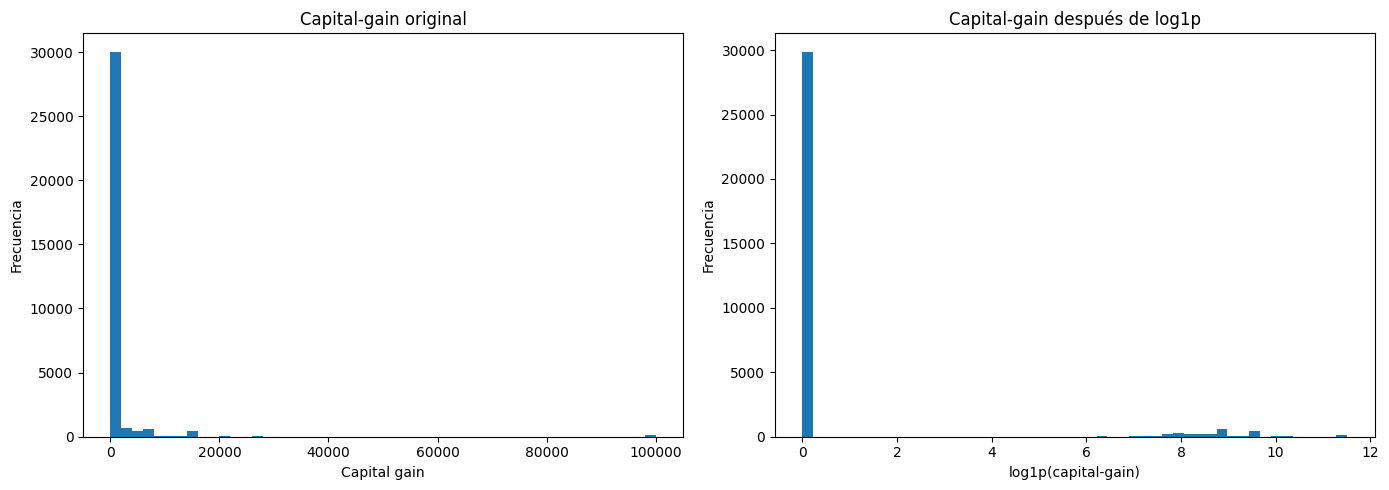

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_reto['capital-gain'], bins=50)
axes[0].set_title('Capital-gain original')
axes[0].set_xlabel('Capital gain')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(capital_gain_log, bins=50)
axes[1].set_title('Capital-gain después de log1p')
axes[1].set_xlabel('log1p(capital-gain)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Outliers multivariados

In [22]:
#Separamos train y test

from sklearn.model_selection import train_test_split

X = df_reto[numeric_cols].copy()

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (26048, 6)
Test: (6513, 6)


In [23]:
#Escalamos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
#Isolation Forest

from sklearn.ensemble import IsolationForest

#Creamos el modelo
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

#Entrenamos el modelo solo con train
iso.fit(X_train_scaled)

iso_pred = iso.predict(X_test_scaled)

iso_outliers = iso_pred == -1

iso_outliers.sum()

np.int64(318)

In [25]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

#Entranamos 
lof.fit(X_train_scaled)

#Predecimos
lof_pred=lof.predict(X_test_scaled)

lof_outliers = lof_pred==-1

lof_outliers.sum()

np.int64(327)

In [26]:
both = iso_outliers & lof_outliers

In [27]:
#Creamos una tabla
comparison = pd.DataFrame({
    'method':['IsolationForest','LOF','Both'],
    'outliers_count':[
        iso_outliers.sum(),
        lof_outliers.sum(),
        both.sum()
    ]
})

comparison

,method,outliers_count
0,IsolationForest,318
1,LOF,327
2,Both,38


# Investiagamos el origen de las anomalías

In [28]:
#Índices de los registros que ambos métodos marcaron
both_index = X_test.index[both]

# Traemos las filas completoas del dataset original 
anomalies = df_reto.loc[both_index].copy()

print('Anomalías detectadas por abmbos:', len(anomalies))
anomalies.head(10)

Anomalías detectadas por abmbos: 38


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
222,90,Private,51744,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,2206,40,United-States,<=50K
32035,40,Private,566537,Preschool,1,Married-civ-spouse,Other-service,Husband,White,Male,0,1672,40,Mexico,<=50K
1291,63,Self-emp-not-inc,795830,1st-4th,2,Widowed,Other-service,Unmarried,White,Female,0,0,30,El-Salvador,<=50K
3578,37,Self-emp-inc,382802,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Black,Male,0,0,99,United-States,>50K
9000,58,Self-emp-not-inc,266707,1st-4th,2,Married-civ-spouse,Transport-moving,Husband,White,Male,0,2179,18,United-States,<=50K
14169,66,Local-gov,376506,Doctorate,16,Divorced,Prof-specialty,Not-in-family,White,Female,3273,0,40,United-States,<=50K
19653,68,Private,32779,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,419,12,United-States,<=50K
29292,54,Private,308087,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,1977,18,United-States,>50K
21657,69,Self-emp-not-inc,204645,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,9386,0,72,United-States,>50K
28652,50,Self-emp-not-inc,42402,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,2415,30,United-States,>50K


In [29]:
#Inspeccionaremos solo 10

sample_anomalies = anomalies.head(10)

#Las clasificaremos 
sample_anomalies = sample_anomalies.copy()

sample_anomalies['classification'] = [
    "Extremo",
    "Señal",
    "Extremo",
    "Extremo",
    "Extremo",
    "Señal",
    "Extremo",
    "Señal",
    "Extremo",
    "Extremo"
]

sample_anomalies[[
    "age","capital-gain","capital-loss",
    "hours-per-week","income","classification"
]]


,age,capital-gain,capital-loss,hours-per-week,income,classification
222,90,0,2206,40,<=50K,Extremo
32035,40,0,1672,40,<=50K,Señal
1291,63,0,0,30,<=50K,Extremo
3578,37,0,0,99,>50K,Extremo
9000,58,0,2179,18,<=50K,Extremo
14169,66,3273,0,40,<=50K,Señal
19653,68,0,419,12,<=50K,Extremo
29292,54,0,1977,18,>50K,Señal
21657,69,9386,0,72,>50K,Extremo
28652,50,0,2415,30,>50K,Extremo


# Banderas de trazabilidad

In [30]:
df_reto['multivariate_outlier'] = False
df_reto.loc[both_index, 'multivariate_outlier'] = True

In [31]:
# Bandera para outliers univariados (IQR)

df_reto['univariate_outlier'] = False

for col in top_3_skewed.index:
    Q1 = df_reto[col].quantile(0.25)
    Q3 = df_reto[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df_reto[col] < lower) | (df_reto[col] > upper)
    df_reto.loc[mask, "univariate_outlier"] = True

df_reto[
    ["univariate_outlier", "multivariate_outlier"]
].sum()

univariate_outlier      5118
multivariate_outlier      38
dtype: int64

## Conclusión

Para un entorno de producción utilizaría principalmente **Isolation Forest** para la detección de anomalías multivariadas. En este dataset no contamos con una etiqueta que indique qué registros son realmente anómalos, por lo que necesitamos un método no supervisado. Isolation Forest permite detectar observaciones aisladas considerando varias variables simultáneamente y puede aplicarse de forma eficiente sobre nuevos datos después de ajustar el modelo con el conjunto de entrenamiento. En producción no eliminaría automáticamente las observaciones detectadas, sino que conservaría una **bandera de anomalía** para mantener la trazabilidad y permitir una revisión posterior. El valor de `contamination` y el umbral de decisión deberían calibrarse con datos históricos y conocimiento del negocio, en lugar de asumir que un porcentaje fijo de registros es incorrecto.

# Tarea 2 - Semana 2

In [32]:
#Hacemos una tabla

shape_stats = pd.DataFrame({
    'skew':df_reto[numeric_cols].skew(),
    'kurtosis': df_reto[numeric_cols].kurt()
}).sort_values('skew', key=abs, ascending=False)

shape_stats

,skew,kurtosis
capital-gain,11.953848,154.799438
capital-loss,4.594629,20.376802
fnlwgt,1.446980,6.218811
age,0.558743,-0.166127
education-num,-0.311676,0.623444
hours-per-week,0.227643,2.916687


In [33]:
#Para identificar las columnas que pide el reto
skewed_cols = shape_stats[shape_stats['skew'].abs() > 1]

skewed_cols

,skew,kurtosis
capital-gain,11.953848,154.799438
capital-loss,4.594629,20.376802
fnlwgt,1.446980,6.218811


### Diagnóstico de distribución

Se calcularon skewness y kurtosis para las variables numéricas. 
Se identificaron como fuertemente sesgadas las variables con |skew| > 1.
Estas variables presentan colas o asimetrías importantes, por lo que se evaluará una transformación Yeo-Johnson.

In [34]:
from sklearn.model_selection import train_test_split

X = df_reto[numeric_cols].copy()

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (26048, 6)
Test: (6513, 6)


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeo_johnson', PowerTransformer(
        method='yeo-johnson',   #Trabaja con +,-,0s
        standardize=False   #Mantiene la escala
    )),
    ('scaler', StandardScaler())
])

In [36]:
#Entrenamos solo con train
X_train_transformed = pipe_num.fit_transform(X_train)

X_test_transformed = pipe_num.transform(X_test)

In [39]:
#Como el pipeline devuelve arrays, volvemos a DataFrames

X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=numeric_cols,
    index=X_train.index
)

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=numeric_cols,
    index=X_test.index
)

In [43]:
comparison_skew = pd.DataFrame({
    "skew_before": X_train[numeric_cols].skew(),
    "skew_after": X_train_transformed_df[numeric_cols].skew()
})

comparison_skew

,skew_before,skew_after
age,0.562900,-0.013464
fnlwgt,1.455058,0.017162
education-num,-0.318322,0.024491
capital-gain,12.141621,3.044369
capital-loss,4.566468,4.269531
hours-per-week,0.228650,0.230962


In [44]:
comparison_skew.sort_values(
    "skew_before",
    key=abs,
    ascending=False
)

,skew_before,skew_after
capital-gain,12.141621,3.044369
capital-loss,4.566468,4.269531
fnlwgt,1.455058,0.017162
age,0.562900,-0.013464
education-num,-0.318322,0.024491
hours-per-week,0.228650,0.230962


### Resultado de la transformación

La transformación Yeo-Johnson redujo la asimetría de las variables numéricas
con mayor skewness. El pipeline fue ajustado exclusivamente sobre el conjunto
de entrenamiento y posteriormente se utilizó para transformar test, evitando
data leakage. Después de la transformación, las distribuciones presentan
colas menos pronunciadas y una escala comparable entre variables.

### ¿Qué pasos sobrarían con un modelo basado en árboles?

Si el modelo final fuera un árbol de decisión o un ensemble basado en árboles,
el `StandardScaler` generalmente no sería necesario porque estos modelos no
dependen de la distancia ni de la escala de las variables. La transformación
Yeo-Johnson tampoco suele ser necesaria para mejorar el funcionamiento del
árbol, aunque podría mantenerse por otros motivos de análisis o consistencia.
La imputación de valores faltantes sí podría seguir siendo necesaria,
dependiendo del modelo utilizado y de su capacidad para manejar NaN.